### 

### Analysis of funtional, gray matter, and white matter structures

In [2]:
# import a excel file
import pandas as pd

path="/home/daniela/Documents/PROJECTS/Aging_DWI/CEDRE/CorrectedTracts2025/"
filename="Subjects_Functional_Structural_Parameters.xlsx"

df_params = pd.read_excel(path + filename, sheet_name="Sheet1")
df_params.head()

,sub,sex,age,group,JND_P,IHD,EstimatedTotalIntraCranialVol,postcentral_lh,precentral_lh,postcentral_rh,precentral_rh,CC_Posterior,CC_Mid_Posterior,CC_Central,CC_Mid_Anterior,CC_Anterior
0,sub-01,F,25,Y,9.56,0.534027,1.601936e+06,12151,13519,11836,13247,993.9,605.0,586.7,666.7,944.6
1,sub-02,M,27,Y,6.69,0.570600,1.902124e+06,12527,16248,13068,16822,1015.4,425.5,400.1,439.6,922.7
2,sub-03,F,28,Y,12.92,-0.140120,1.730076e+06,13346,14411,11596,14849,723.5,446.6,717.7,571.2,708.0
3,sub-05,F,21,Y,1.95,0.488581,1.714908e+06,11553,13616,11595,13756,888.9,444.6,444.4,395.5,840.7
4,sub-06,F,25,Y,2.54,0.578001,1.546827e+06,9204,12872,9348,12538,770.1,476.4,658.5,563.1,703.9


In [3]:
# Pre-processing the data
# Relative measure of the volume mesures, for all columns, to the estimated total intracranial volume for each subject

df_params= df_params.rename(columns={"EstimatedTotalIntraCranialVol": "eTIV"})

# Assuming 'ICV' is the column name for intracranial volume in your DataFrame
colums_to_normalize = ["postcentral_lh", "precentral_lh", "postcentral_rh", "precentral_rh", "CC_Posterior", "CC_Mid_Posterior", "CC_Central", "CC_Mid_Anterior", "CC_Anterior"]

df_params_norm = df_params.copy()
for col in colums_to_normalize:
    df_params_norm[col] = (df_params_norm[col] / df_params_norm['eTIV']) #* 1000  # Scale to per 1000 units of intracranial volume
df_params_norm.head()

,sub,sex,age,group,JND_P,IHD,eTIV,postcentral_lh,precentral_lh,postcentral_rh,precentral_rh,CC_Posterior,CC_Mid_Posterior,CC_Central,CC_Mid_Anterior,CC_Anterior
0,sub-01,F,25,Y,9.56,0.534027,1.601936e+06,0.007585,0.008439,0.007389,0.008269,0.000620,0.000378,0.000366,0.000416,0.000590
1,sub-02,M,27,Y,6.69,0.570600,1.902124e+06,0.006586,0.008542,0.006870,0.008844,0.000534,0.000224,0.000210,0.000231,0.000485
2,sub-03,F,28,Y,12.92,-0.140120,1.730076e+06,0.007714,0.008330,0.006703,0.008583,0.000418,0.000258,0.000415,0.000330,0.000409
3,sub-05,F,21,Y,1.95,0.488581,1.714908e+06,0.006737,0.007940,0.006761,0.008021,0.000518,0.000259,0.000259,0.000231,0.000490
4,sub-06,F,25,Y,2.54,0.578001,1.546827e+06,0.005950,0.008322,0.006043,0.008106,0.000498,0.000308,0.000426,0.000364,0.000455


###  Basic correlations analysis 

Correlation between postcentral_lh and JND for group Y: r=0.04, p=0.8466
Correlation between postcentral_lh and JND for group O: r=-0.50, p=0.0225
Correlation between precentral_lh and JND for group Y: r=-0.28, p=0.2232
Correlation between precentral_lh and JND for group O: r=0.06, p=0.7809
Correlation between postcentral_rh and JND for group Y: r=0.20, p=0.3798
Correlation between postcentral_rh and JND for group O: r=-0.37, p=0.0947
Correlation between precentral_rh and JND for group Y: r=-0.07, p=0.7500
Correlation between precentral_rh and JND for group O: r=-0.26, p=0.2557
Correlation between CC_Posterior and JND for group Y: r=0.10, p=0.6544
Correlation between CC_Posterior and JND for group O: r=0.29, p=0.2100
Correlation between CC_Mid_Posterior and JND for group Y: r=0.06, p=0.8099
Correlation between CC_Mid_Posterior and JND for group O: r=-0.08, p=0.7415
Correlation between CC_Central and JND for group Y: r=0.29, p=0.2103
Correlation between CC_Central and JND for group O: r

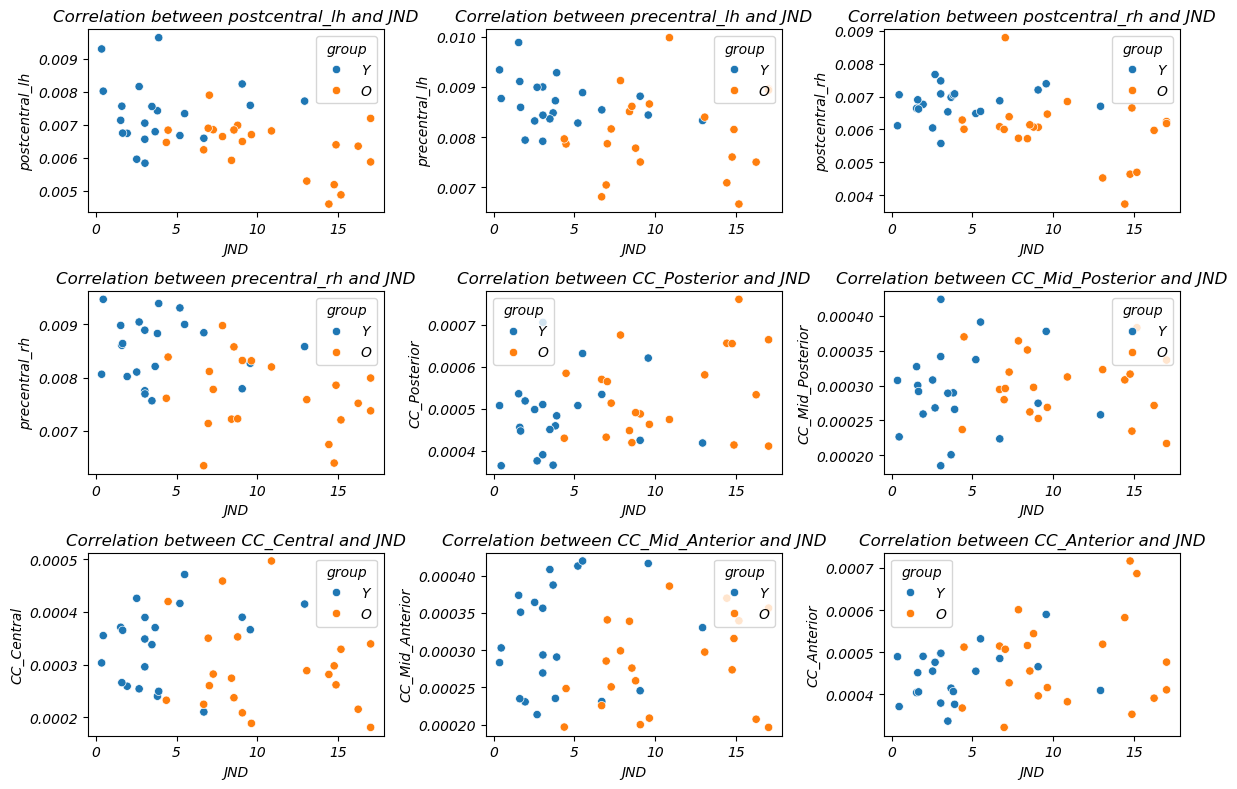

In [4]:
# plot correlations between JND and the Gray Matter volume measures, using the normalized values. using seaborn and matplotlib
# Scatter plot for each volume measure against JND, and calculate the correlation coefficient.
# four subplots, with separated colors pour each group (young and old)

import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# List of volume measures to plot
volume_measures = ["postcentral_lh", "precentral_lh", "postcentral_rh", "precentral_rh", "CC_Posterior", "CC_Mid_Posterior", "CC_Central", "CC_Mid_Anterior", "CC_Anterior"]
# Create a figure with 2 rows and 2 columns of subplots
fig, axes = plt.subplots(3, 3, figsize=(12, 8))
# Flatten the axes array for easy iteration
axes = axes.flatten()
# Loop through each volume measure and create a scatter plot
for i, measure in enumerate(volume_measures):
    sns.scatterplot(data=df_params_norm, x="JND_P",y=measure,  hue="group", ax=axes[i])
    axes[i].set_title(f"Correlation between {measure} and JND")
    axes[i].set_xlabel("JND")
    axes[i].set_ylabel(f"{measure}")  

    # Calculate correlation for each group: print r and p values
    for group in df_params_norm['group'].unique():
        group_data = df_params_norm[df_params_norm['group'] == group]
        r, p = pearsonr(group_data["JND_P"], group_data[measure])
        print(f"Correlation between {measure} and JND for group {group}: r={r:.2f}, p={p:.4f}")

    # Correlation line to the plot,for each group


# Adjust layout and show the plot
plt.tight_layout()
plt.show()  


In [15]:
# regression analysis between JND and the volume measures, using statsmodels, with group as a covariate. 
# print the summary of the regression results for each model.
import statsmodels.formula.api as smf

df_params_scaled= df_params_norm.copy()

# Loop through each volume measure and perform regression analysis
for measure in volume_measures:
    # scaling and centering the volume measures
    df_params_scaled[measure] = (df_params_scaled[measure] - df_params_scaled[measure].mean()) / df_params_scaled[measure].std()
    df_params_scaled['JND_P'] = (df_params_scaled['JND_P'] - df_params_scaled['JND_P'].mean()) / df_params_scaled['JND_P'].std()

    formula = f"JND_P ~ {measure} : group"
    model = smf.ols(formula, data=df_params_scaled).fit()
    print(f"Regression analysis for {measure}:\n")
    print(model.summary())
    print("\n\n")   


Regression analysis for postcentral_lh:

                            OLS Regression Results                            
Dep. Variable:                  JND_P   R-squared:                       0.315
Model:                            OLS   Adj. R-squared:                  0.279
Method:                 Least Squares   F-statistic:                     8.948
Date:                Wed, 08 Apr 2026   Prob (F-statistic):           0.000633
Time:                        10:46:19   Log-Likelihood:                -51.159
No. Observations:                  42   AIC:                             108.3
Df Residuals:                      39   BIC:                             113.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------

Interaction Term -->
postcentral_lh:group[T.Y] (2.7160): This is an interaction effect. It means the relationship between postcentral_lh and JND_P differs between groups. Specifically, the negative effect of postcentral_lh on JND_P is less strong (or even reversed) for group Y compared to the reference group.

Group Differences--> Group Y has significantly lower JND_P scores than the reference group.
Brain Region Effect: Higher postcentral_lh values are associated with lower JND_P, but this effect is weaker (or reversed) for group Y.


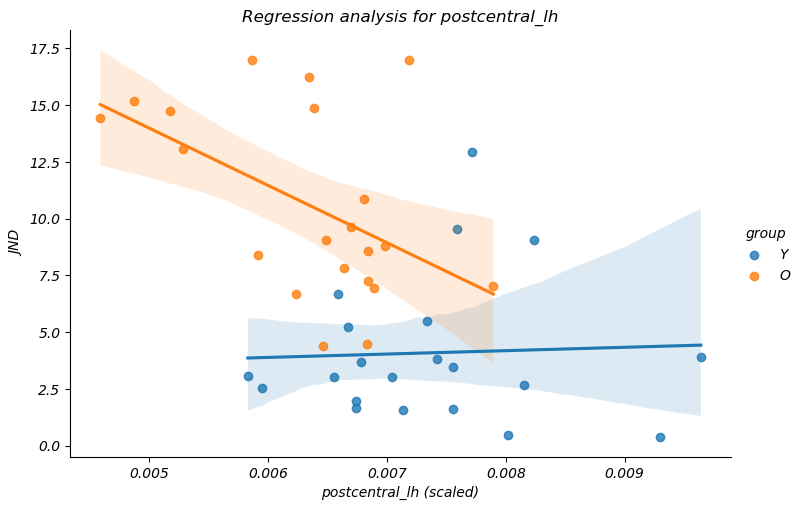

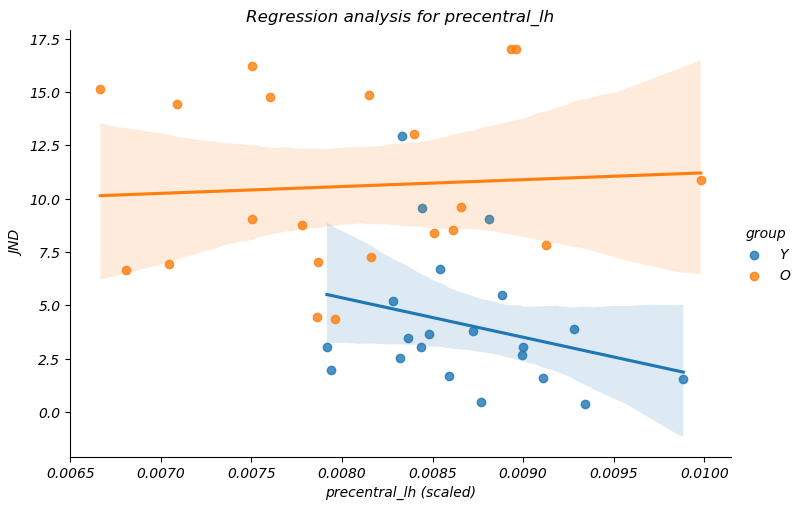

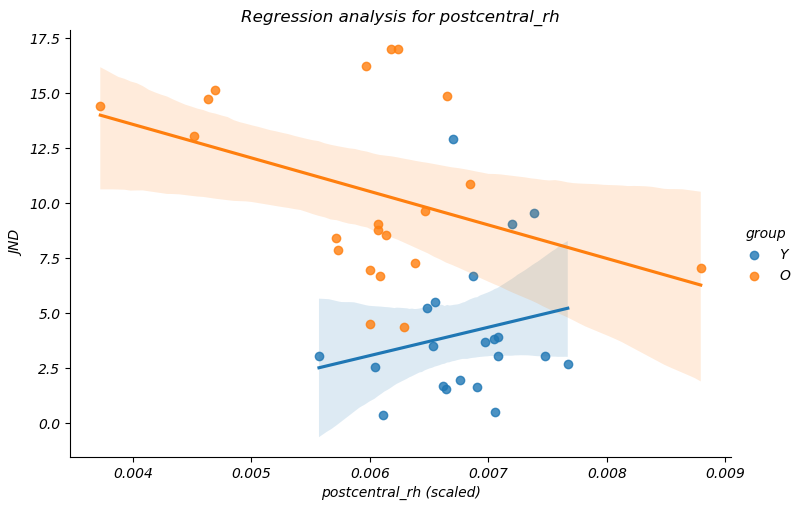

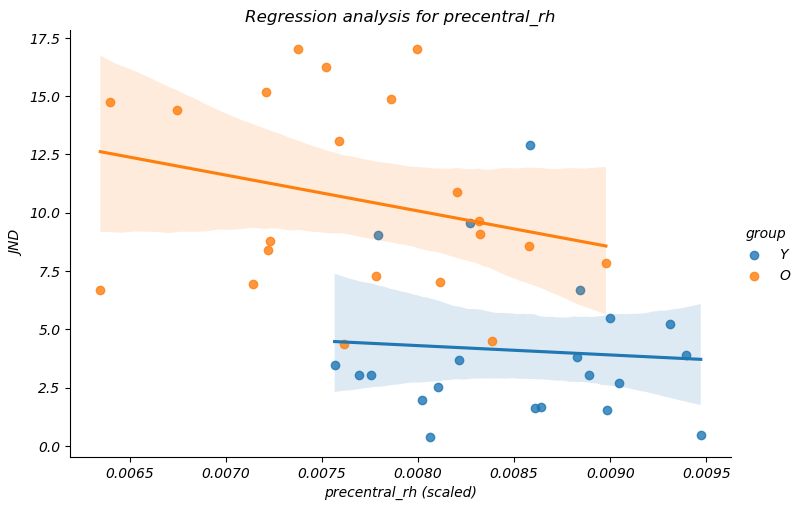

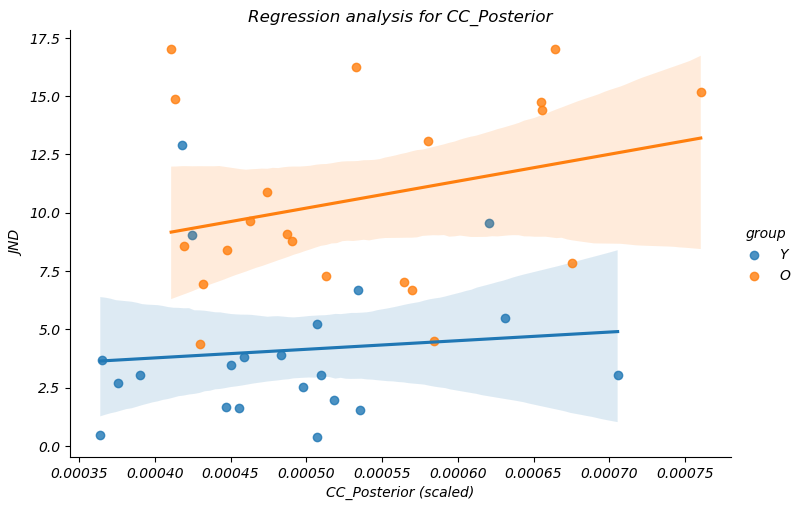

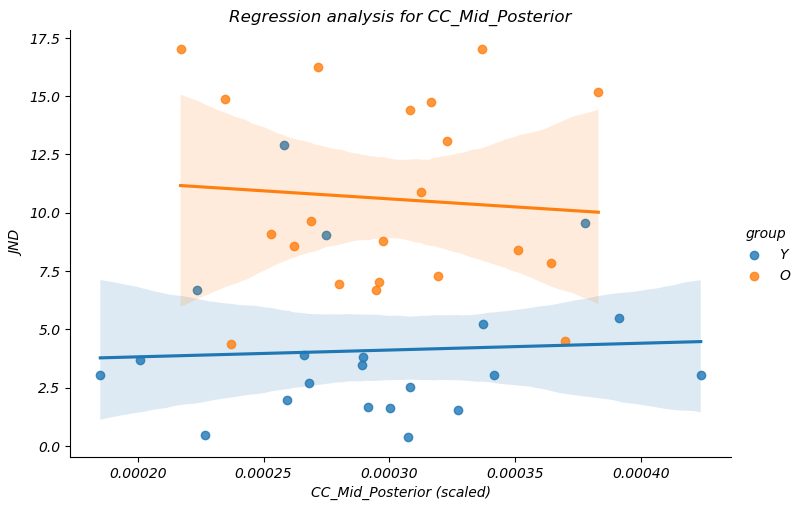

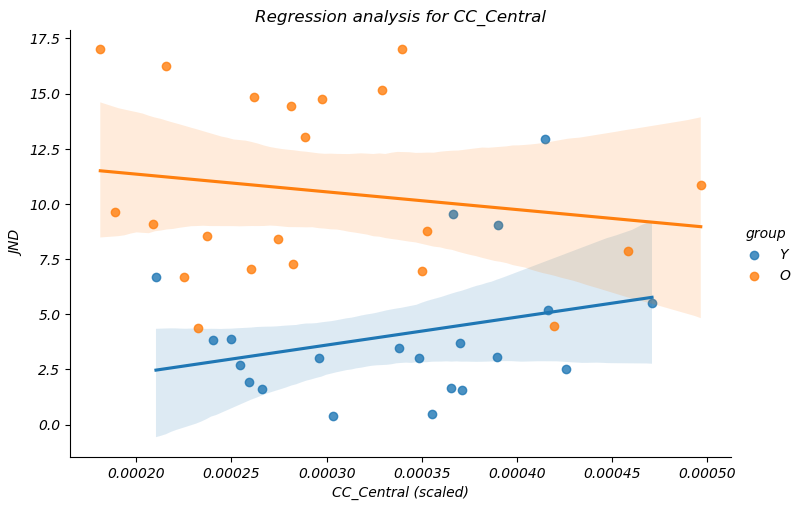

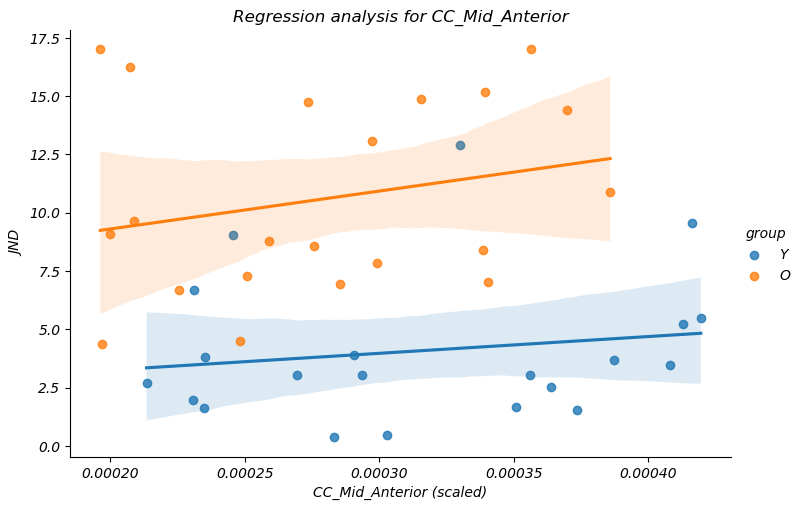

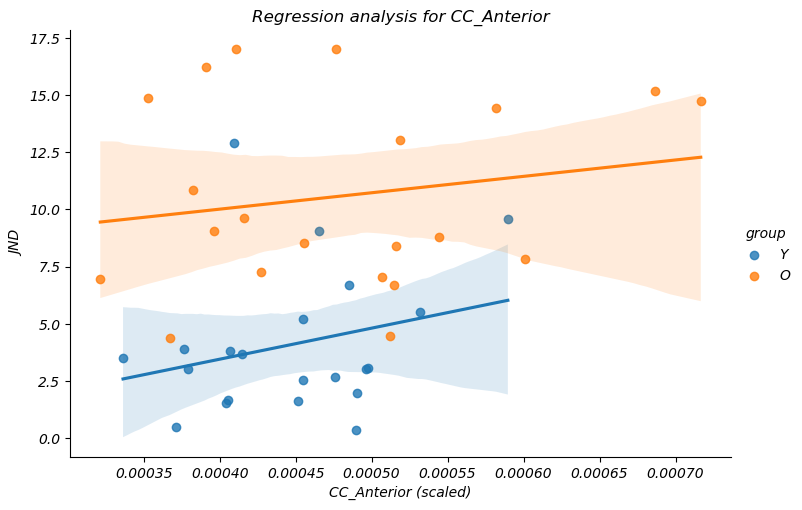

In [6]:
# plot the regression analysis results: model
# show the regression line for each group separately.

# subplots for each volume measure, with group as a hue
for measure in volume_measures:
    #figure size
    sns.lmplot(data=df_params_norm, x=measure, y="JND_P", hue="group", aspect=1.5)
    plt.title(f"Regression analysis for {measure}")
    plt.xlabel(f"{measure} (scaled)")
    plt.ylabel("JND")
    plt.show()

# IHD analysis

In [7]:
# regression analysis between IHD and the volume measures,
import statsmodels.formula.api as smf

# Loop through each volume measure and perform regression analysis
for measure in volume_measures:
    #scaled IHD
    df_params_scaled['IHD'] = (df_params_scaled['IHD'] - df_params_scaled['IHD'].mean()) / df_params_scaled['IHD'].std()

    formula = f"IHD ~ {measure} * age"
    model = smf.ols(formula, data=df_params_scaled).fit()
    print(f"Regression analysis for {measure}:\n")
    print(model.summary())
    print("\n\n")   

Regression analysis for postcentral_lh:

                            OLS Regression Results                            
Dep. Variable:                    IHD   R-squared:                       0.431
Model:                            OLS   Adj. R-squared:                  0.378
Method:                 Least Squares   F-statistic:                     8.087
Date:                Wed, 08 Apr 2026   Prob (F-statistic):           0.000378
Time:                        10:45:19   Log-Likelihood:                -40.418
No. Observations:                  36   AIC:                             88.84
Df Residuals:                      32   BIC:                             95.17
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------

In [8]:
# read the file:  All_AgingDTI_VoxelFA.xlsx
import pandas as pd

CC_ROIs_path="/home/daniela/Documents/PROJECTS/Aging_DWI/CC_segmentation_voxel"
file_name="All_AgingDTI_VoxelFA.xlsx"

df_CC_FA = pd.read_excel(f'{CC_ROIs_path}/{file_name}')
df_CC_FA.rename(columns={'Subject': 'sub'}, inplace=True)

# Define the path to the subject ID list and the output path for the CSV file
sub_ID_path="/home/daniela/Documents/PROJECTS/Aging_DWI/CEDRE/CorrectedTracts2025"
sub_file_name="Subjects_Functional_Structural_Parameters.xlsx"

df_sub_ID = pd.read_excel(f'{sub_ID_path}/{sub_file_name}')

# merge the two dataframes on the 'sub' column
merged_df = pd.merge(df_sub_ID, df_CC_FA, on='sub', how='inner')

# remove variables
columns_to_remove = ['CC_Anterior', 'CC_Mid_Anterior', 'CC_Central', 'CC_Mid_Posterior', 'CC_Posterior', 'postcentral_lh', 'postcentral_rh', 'precentral_lh', 'precentral_rh', 'EstimatedTotalIntraCranialVol']
merged_df.drop(columns=columns_to_remove, inplace=True)
merged_df.head()


,sub,sex,age,group,JND_P,IHD,CC_1_ROI,CC_2_ROI,CC_3_ROI,CC_4_ROI,CC_5_ROI,CC_6_ROI,CC_7_ROI
0,sub-01,F,25,Y,9.56,0.534027,0.411479,0.666939,0.553500,0.597222,0.545191,0.617076,0.706386
1,sub-02,M,27,Y,6.69,0.570600,0.420321,0.700882,0.639006,0.648683,0.594659,0.677801,0.736987
2,sub-03,F,28,Y,12.92,-0.140120,0.388947,0.718711,0.616378,0.645037,0.635727,0.687744,0.766117
3,sub-05,F,21,Y,1.95,0.488581,0.348544,0.689371,0.584109,0.601705,0.578431,0.651975,0.753408
4,sub-06,F,25,Y,2.54,0.578001,0.457281,0.704973,0.644411,0.638733,0.666153,0.740253,0.782395


In [9]:
# multiple regression analysis with JND as the dependent variable, and the FA values of the CC segments as independent variables, with age as a covariate.
import statsmodels.formula.api as smf

variables_to_scale = ['CC_1_ROI', 'CC_2_ROI', 'CC_3_ROI', 'CC_4_ROI', 'CC_5_ROI', 'CC_6_ROI', 'CC_7_ROI', 'JND_P', 'IHD']
df_scaled= merged_df.copy()
# scale the variables
#for var in variables_to_scale:
#    df_scaled[var] = (df_scaled[var] - df_scaled[var].mean()) / df_scaled[var].std()

# loop across the CC segments and perform regression analysis
for i in range(1, 8):
    formula = f"JND_P ~ CC_{i}_ROI : group"
    model = smf.ols(formula, data=df_scaled).fit()
    print(f"Regression analysis for CC_{i}_ROI:\n")
    print(model.summary())
    print("\n\n")   



Regression analysis for CC_1_ROI:

                            OLS Regression Results                            
Dep. Variable:                  JND_P   R-squared:                       0.472
Model:                            OLS   Adj. R-squared:                  0.445
Method:                 Least Squares   F-statistic:                     17.45
Date:                Wed, 08 Apr 2026   Prob (F-statistic):           3.86e-06
Time:                        10:45:19   Log-Likelihood:                -112.48
No. Observations:                  42   AIC:                             231.0
Df Residuals:                      39   BIC:                             236.2
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Int

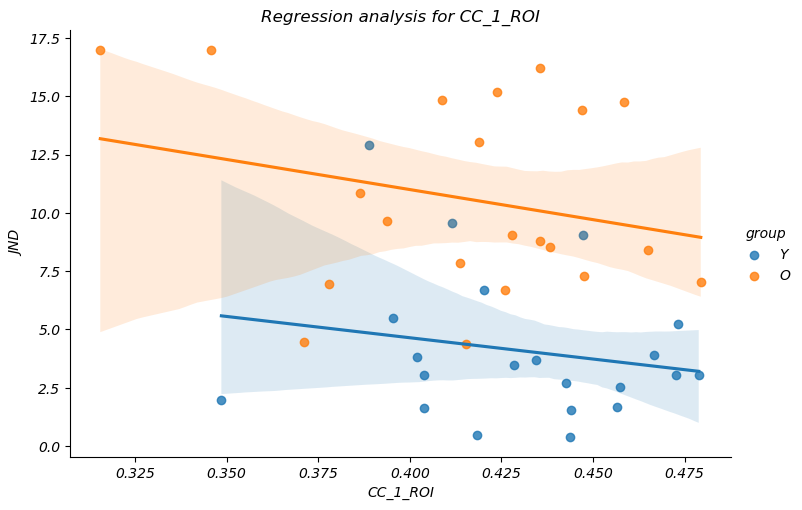

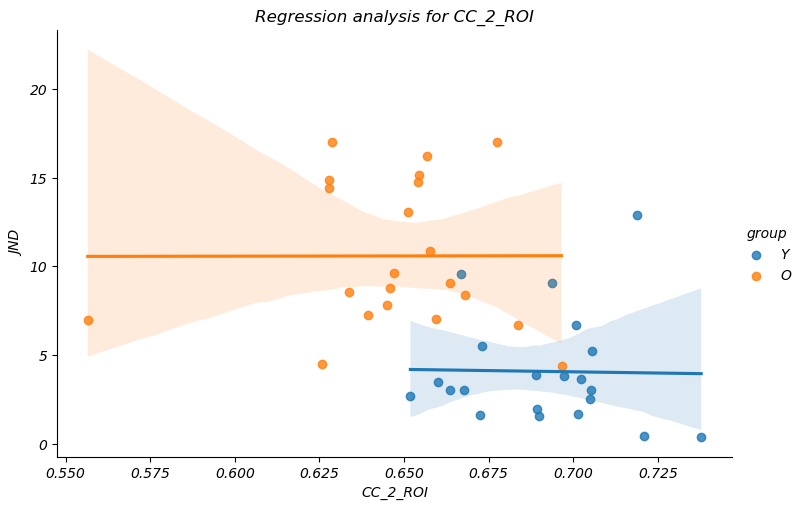

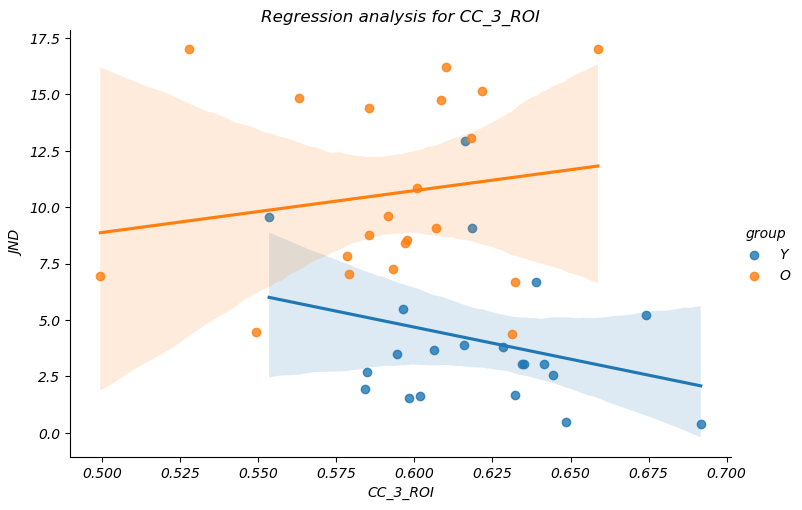

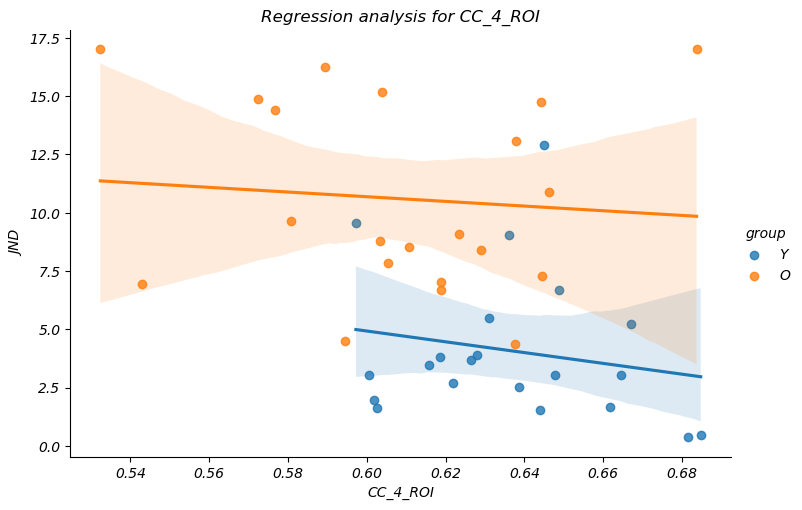

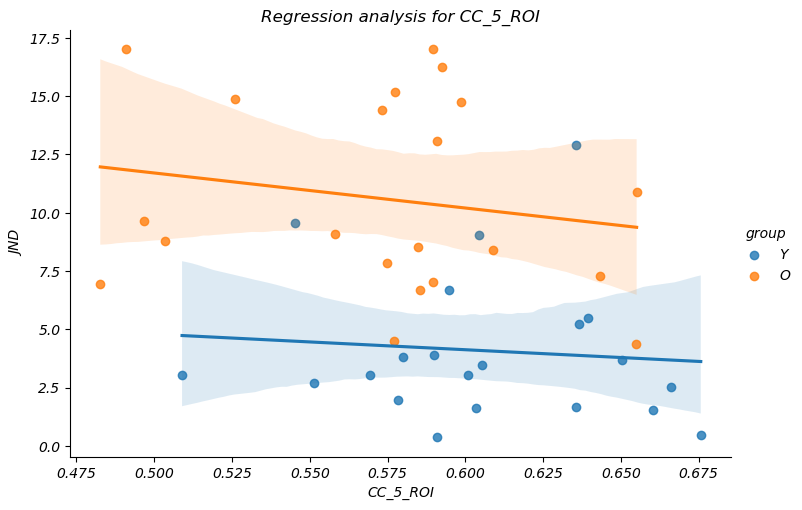

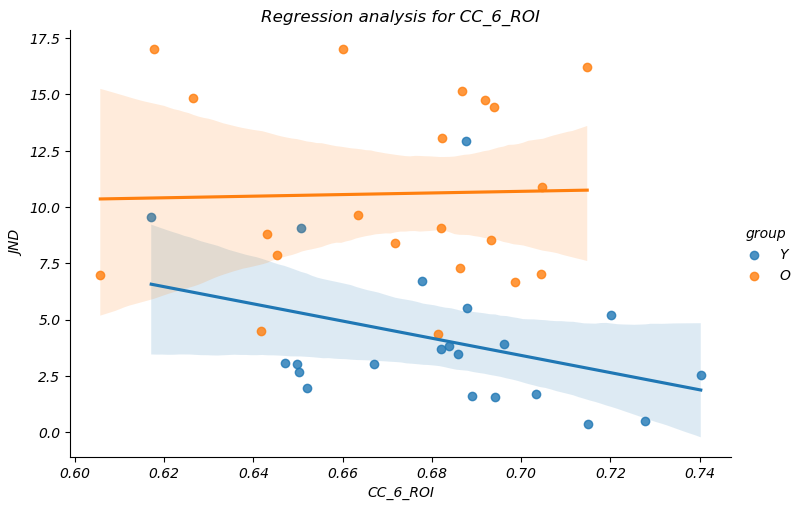

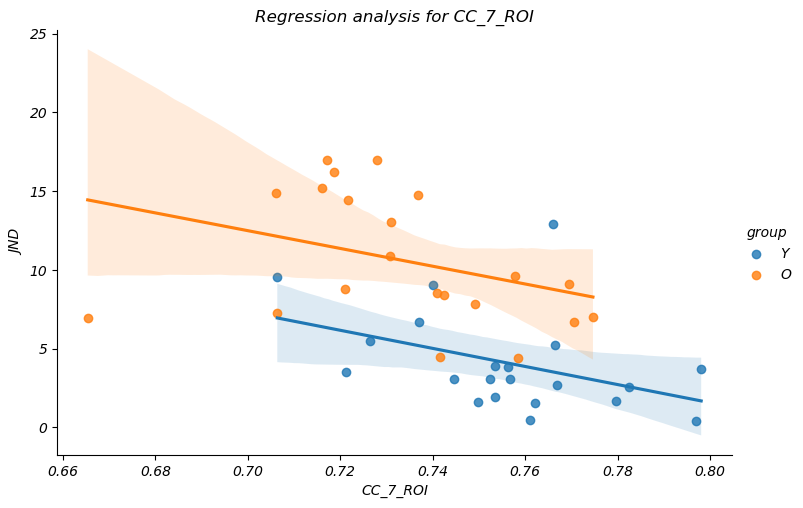

In [10]:

# subplots for each volume measure, with group as a hue
for i in range(1, 8):
    measure = f"CC_{i}_ROI"
    #figure size
    sns.lmplot(data=df_scaled, x=measure, y="JND_P", hue="group", aspect=1.5)
    plt.title(f"Regression analysis for {measure}")
    plt.xlabel(f"{measure}")
    plt.ylabel("JND")
    plt.show()

In [11]:
# loop across the CC segments and perform regression analysis
for i in range(1, 8):
    formula = f"JND_P ~ CC_{i}_ROI * age"
    model = smf.ols(formula, data=df_scaled).fit()
    print(f"Regression analysis for CC_{i}_ROI:\n")
    print(model.summary())
    print("\n\n")   

Regression analysis for CC_1_ROI:

                            OLS Regression Results                            
Dep. Variable:                  JND_P   R-squared:                       0.523
Model:                            OLS   Adj. R-squared:                  0.486
Method:                 Least Squares   F-statistic:                     13.91
Date:                Wed, 08 Apr 2026   Prob (F-statistic):           2.85e-06
Time:                        10:45:20   Log-Likelihood:                -110.34
No. Observations:                  42   AIC:                             228.7
Df Residuals:                      38   BIC:                             235.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept    

In [12]:
# regressiong for IHD
# loop across the CC segments and perform regression analysis
for i in range(1, 8):
    formula = f"IHD ~ CC_{i}_ROI * group"
    model = smf.ols(formula, data=df_scaled).fit()
    print(f"Regression analysis for CC_{i}_ROI:\n")
    print(model.summary())
    print("\n\n")   

Regression analysis for CC_1_ROI:

                            OLS Regression Results                            
Dep. Variable:                    IHD   R-squared:                       0.407
Model:                            OLS   Adj. R-squared:                  0.352
Method:                 Least Squares   F-statistic:                     7.333
Date:                Wed, 08 Apr 2026   Prob (F-statistic):           0.000710
Time:                        10:45:20   Log-Likelihood:                -7.1745
No. Observations:                  36   AIC:                             22.35
Df Residuals:                      32   BIC:                             28.68
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------

## Mediation Model

In [13]:
#!pip install pingouin

In [17]:
import pandas as pd
import statsmodels.api as sm
from pingouin import mediation_analysis

df_CCs = merged_df.copy()

for i in range(1, 8):
    cc_FA_ROIs = f"CC_{i}_ROI"  # Use a single string for the current region
    data = pd.DataFrame({
        'age': df_CCs["age"],
        'JND': df_CCs["JND_P"],
        'IHD': df_CCs["IHD"],
        'CCvar': df_CCs[cc_FA_ROIs],
    })
    # Mediation analysis
    mediation_results = mediation_analysis(data=data, x='age', y='JND', m='CCvar', seed=42)
    print(f"Results for {cc_FA_ROIs}:")
    print(mediation_results)
    print("\n")

Results for CC_1_ROI:
        path       coef         se          pval      CI2.5    CI97.5  sig
0  CCvar ~ X  -0.000271   0.000243  2.719798e-01  -0.000763  0.000221   No
1  Y ~ CCvar -39.671139  20.053911  5.481958e-02 -80.201605  0.859328   No
2      Total   0.145284   0.023485  2.585873e-07   0.097819  0.192748  Yes
3     Direct   0.138698   0.023372  6.389860e-07   0.091423  0.185973  Yes
4   Indirect   0.006585   0.009349  3.000000e-01  -0.001944  0.036750   No


Results for CC_2_ROI:
        path       coef         se          pval       CI2.5     CI97.5  sig
0  CCvar ~ X  -0.000898   0.000172  5.948936e-06   -0.001246  -0.000550  Yes
1  Y ~ CCvar -65.618941  20.841866  3.099823e-03 -107.741925 -23.495958  Yes
2      Total   0.145284   0.023485  2.585873e-07    0.097819   0.192748  Yes
3     Direct   0.145110   0.030827  3.140447e-05    0.082756   0.207464  Yes
4   Indirect   0.000173   0.026607  9.640000e-01   -0.053095   0.053374   No


Results for CC_3_ROI:
        path      

In [18]:
# interation between CC and JND, mediated by age

for i in range(1, 8):
    cc_FA_ROIs = f"CC_{i}_ROI"  # Use a single string for the current region
    data = pd.DataFrame({
        'age': df_CCs["age"],
        'IHD': df_CCs["IHD"],
        'JND': df_CCs["JND_P"],
        'group': df_CCs["group"],
        'CCvar': df_CCs[cc_FA_ROIs],
    })
    # Mediation analysis
    mediation_results = mediation_analysis(data=data, x='CCvar', y='JND', m='age', seed=42)
    print(f"Results for {cc_FA_ROIs}:")
    print(mediation_results)
    print("\n")

Results for CC_1_ROI:
       path        coef         se          pval       CI2.5     CI97.5  sig
0   age ~ X -110.939886  99.597795  2.719798e-01 -312.234538  90.354766   No
1   Y ~ age    0.145284   0.023485  2.585873e-07    0.097819   0.192748  Yes
2     Total  -39.671139  20.053911  5.481958e-02  -80.201605   0.859328   No
3    Direct  -24.283975  14.949038  1.123355e-01  -54.521258   5.953308   No
4  Indirect  -15.387164  12.320373  2.120000e-01  -38.429050   9.454298   No


Results for CC_2_ROI:
       path        coef         se          pval       CI2.5      CI97.5  sig
0   age ~ X -450.870394  86.452109  5.948936e-06 -625.596625 -276.144163  Yes
1   Y ~ age    0.145284   0.023485  2.585873e-07    0.097819    0.192748  Yes
2     Total  -65.618941  20.841866  3.099823e-03 -107.741925  -23.495958  Yes
3    Direct   -0.192971  21.847005  9.929975e-01  -44.382710   43.996768   No
4  Indirect  -65.425971  22.020491  0.000000e+00 -119.196248  -33.687308  Yes


Results for CC_3_ROI:


In [ ]:
# mediation model with volumetric measures, using the normalized values.
# from the data frame : df_params_norm

variables_volumetric = ["postcentral_lh", "precentral_lh", "postcentral_rh", "precentral_rh"]

for i in range(1, 5):
    data = pd.DataFrame({
        'age': df_CCs["age"],
        'IHD': df_CCs["IHD"],
        'JND': df_CCs["JND_P"],
        'VolVar': df_params_norm[variables_volumetric[i-1]],
    })
    # Mediation analysis
    mediation_results = mediation_analysis(data=data, x='age', y='JND', m='VolVar', seed=42)
    print(f"Results for {variables_volumetric[i-1]}:")
    print(mediation_results)
    print("\n")

Results for postcentral_lh:
         path         coef          se          pval        CI2.5  \
0  VolVar ~ X    -0.000023    0.000006  2.044634e-04    -0.000035   
1  Y ~ VolVar -2359.377046  666.631667  1.034311e-03 -3706.689904   
2       Total     0.145284    0.023485  2.585873e-07     0.097819   
3      Direct     0.127887    0.027849  4.492585e-05     0.071558   
4    Indirect     0.017397    0.015093  2.280000e-01    -0.010030   

        CI97.5  sig  
0    -0.000012  Yes  
1 -1012.064189  Yes  
2     0.192748  Yes  
3     0.184216  Yes  
4     0.048690   No  


Results for precentral_lh:
         path         coef          se          pval        CI2.5     CI97.5  \
0  VolVar ~ X    -0.000014    0.000004  3.001712e-03    -0.000023  -0.000005   
1  Y ~ VolVar -2082.760605  992.388594  4.219971e-02 -4088.452770 -77.068440   
2       Total     0.145284    0.023485  2.585873e-07     0.097819   0.192748   
3      Direct     0.145005    0.026588  2.966138e-06     0.091226   0.198783